In [ ]:
import sympy as sp
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # necesario para 3D
from matplotlib import cm # colormap

from tabulate import tabulate
from IPython.display import HTML, display
import matplotlib.animation as animation

plt.rcParams['figure.figsize'] = (8,5)

In [ ]:
def f(x):
  return 1 - 4*(x-0.05)**2

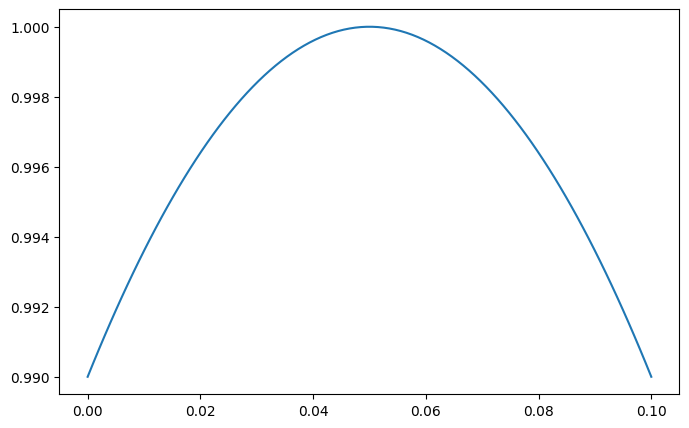

In [ ]:
x=np.linspace(0,0.1,100)
plt.plot(x,f(x))

In [ ]:
def tridiagonal(n, a, b):
  return sp.Matrix([
      [a if i == j else b if abs (i-j) == 1 else 0 for j in range (n)]
      for i in range (n)
  ])

In [ ]:

r=1

In [ ]:
A= tridiagonal (9, 2 + 2*r, -r)
B = tridiagonal(9, 2 - 2*r,  r)

In [ ]:
A=sp.Matrix([[4, -1, 0, 0, 0, 0, 0, 0, 0],
            [-1, 4, -1, 0, 0, 0, 0, 0, 0],
            [0, -1, 4, -1, 0, 0, 0, 0, 0],
            [0, 0, -1, 4, -1, 0, 0, 0, 0],
            [0, 0, 0, -1, 4, -1, 0, 0, 0],
            [0, 0, 0, 0, -1, 4, -1, 0, 0],
            [0, 0, 0, 0, 0, -1, 4, -1, 0],
            [0, 0, 0, 0, 0, 0, -1, 4, -1],
            [0, 0, 0, 0, 0, 0, 0, -1, 4,]])

In [ ]:
b = sp.Matrix([f(0.01*(i+1)) for i in range (9)])

In [ ]:
b

Matrix([
[0.9936],
[0.9964],
[0.9984],
[0.9996],
[   1.0],
[0.9996],
[0.9984],
[0.9964],
[0.9936]])

In [ ]:
def crank_nicolson (A, B, b, j):
  b_1 = B * b            #mismo para inicial de tu función
  S = []                 #aquí guardaremos cada solución

  for i in range (j):
    sol = A. LUsolve(b_1)      #u^(n+1)
    S.append(sol.T)            # guardar fila (como vector renglón)
    b_1 = B*sol                # preparar siguiente paso

  # Convertir lista de vectores sympy a una matriz sympy
  return sp.Matrix(S)

In [ ]:
U = crank_nicolson(A, B, b, 50)   # puedes elegir j=50 o el número que tú uses
U_np = np.array(U.tolist(), dtype=float)
j = 50


In [ ]:
x = np.linspace (0, 1, 9) #Número de nodos internos en X
y = np.linspace (0, 0.5, j) #Debe coincidir con el tamaño de j por k (tiempo)
X, Y = np.meshgrid(x,y)

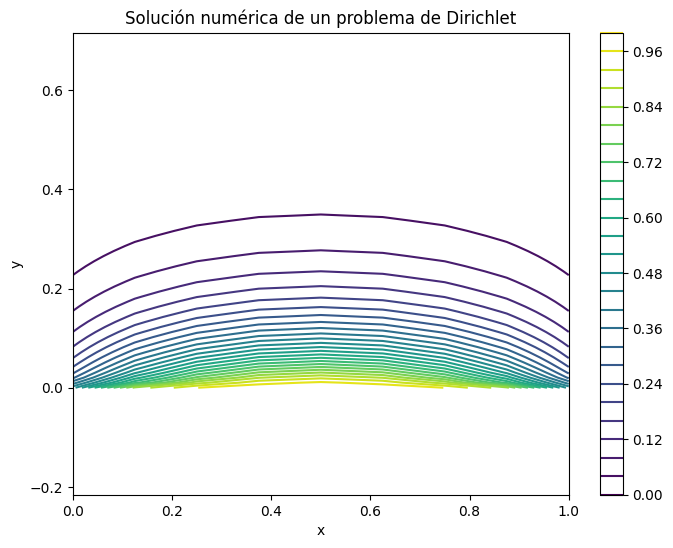

In [ ]:
#Mapa de colores
plt.figure(figsize=(8,6))
contour = plt.contour(X, Y, U_np, levels=25, cmap=cm.viridis)
plt.colorbar(contour)
plt.title("Solución numérica de un problema de Dirichlet")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

In [ ]:
data = [list(U.row(1)) for i in range (5)]

print (tabulate(data, tablefmt="grld"))

--------  --------  --------  --------  --------  --------  --------  --------  --------
0.379929  0.666267  0.863348  0.945812  0.966838  0.945812  0.863348  0.666267  0.379929
0.379929  0.666267  0.863348  0.945812  0.966838  0.945812  0.863348  0.666267  0.379929
0.379929  0.666267  0.863348  0.945812  0.966838  0.945812  0.863348  0.666267  0.379929
0.379929  0.666267  0.863348  0.945812  0.966838  0.945812  0.863348  0.666267  0.379929
0.379929  0.666267  0.863348  0.945812  0.966838  0.945812  0.863348  0.666267  0.379929
--------  --------  --------  --------  --------  --------  --------  --------  --------
